# Hierarchikus Klaszterezés - Bank Marketing Dataset
## Agglomeratív (Ward módszer) - Age és Balance

### Célkitűzések:
- Hierarchikus (Agglomeratív) klaszterezés
- 2 változó: **age** (életkor) és **balance_win** (winsorizált egyenleg)
- Ward linkage módszer
- Klaszterszám tesztelése: k=2-től k=8-ig
- Dendrogram vizualizáció vágási pontokkal
- Validációs metrikák és optimális k kiválasztása
- **Exportálás: exports_hacluster/ mappába**

## 1. Könyvtárak importálása

In [29]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Scipy hierarchikus klaszterezéshez
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Könyvtárak sikeresen betöltve!")

✓ Könyvtárak sikeresen betöltve!


## 2. Adatok betöltése és előkészítése

In [30]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print("="*70)
print("ADATOK BETÖLTÉSE")
print("="*70)
print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor (age, balance):")
print(df[['age', 'balance']].head())
print("\nStatisztikák:")
print(df[['age', 'balance']].describe())

ADATOK BETÖLTÉSE
Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor (age, balance):
   age  balance
0   58     2143
1   44       29
2   33        2
3   47     1506
4   33        1

Statisztikák:
                age        balance
count  45211.000000   45211.000000
mean      40.936210    1362.272058
std       10.618762    3044.765829
min       18.000000   -8019.000000
25%       33.000000      72.000000
50%       39.000000     448.000000
75%       48.000000    1428.000000
max       95.000000  102127.000000


In [31]:
# Winsorization (1-99 percentilis)
from scipy.stats.mstats import winsorize
df['balance_win'] = winsorize(df['balance'], limits=[0.01, 0.01])
print("="*70)
print("Winsorization kész")
print("="*70)

Winsorization kész


In [ ]:
"""
# 10%-OS STRATIFIKÁLT MINTAVÉTEL
from sklearn.model_selection import train_test_split
# Stratifikált mintavétel train_test_split segítségével
df_sample, _ = train_test_split(
    df, 
    test_size=0.9,      # 90%-ot eldobunk
    stratify=df['y'],   # Stratifikálás az 'y' változó szerint
    random_state=42
)

print(f"10%-os minta mérete: {len(df_sample)} sor")
print(f"Eredeti 'y' eloszlás:\n{df['y'].value_counts(normalize=True)}")
print(f"\nMinta 'y' eloszlás:\n{df_sample['y'].value_counts(normalize=True)}")
"""

10%-os minta mérete: 4521 sor
Eredeti 'y' eloszlás:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

Minta 'y' eloszlás:
y
no     0.88299
yes    0.11701
Name: proportion, dtype: float64


In [ ]:
# Feature Selection: age és balance_win
features = ['age', 'balance_win']
X = df[features].copy()
#X = df_sample[['age', 'balance_win']].copy()

print("\n" + "="*70)
print("FEATURE SELECTION ÉS NORMALIZÁLÁS")
print("="*70)
print(f"Kiválasztott változók: {features}")
print(f"Adatpontok száma: {len(X):,}")

# Normalizálás: StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

print("\n✓ Adatok normalizálva (StandardScaler)!")
print(f"  data_scaled alakja: {data_scaled.shape}")
print(f"  Átlag: {data_scaled.mean(axis=0)}")
print(f"  Szórás: {data_scaled.std(axis=0)}")


FEATURE SELECTION ÉS NORMALIZÁLÁS
Kiválasztott változók: ['age', 'balance_win']
Adatpontok száma: 4,521

✓ Adatok normalizálva (StandardScaler)!
  data_scaled alakja: (4521, 2)
  Átlag: [-1.83882991e-16 -3.14329899e-17]
  Szórás: [1. 1.]


## 3. Hierarchikus Klaszterezés - Linkage Számítás (Ward)

In [35]:
# Hierarchikus klaszterezés - Ward linkage
print("="*70)
print("HIERARCHIKUS KLASZTEREZÉS - LINKAGE SZÁMÍTÁS")
print("="*70)
print("Linkage módszer: Ward")
print(f"Adatpontok száma: {len(data_scaled):,}")
print("\nLinkage számítása (ez eltarthat néhány percig nagy adatnál)...")

# Ward linkage számítása
Z = linkage(data_scaled, method='ward')

print("\n✓ Linkage mátrix kiszámítva!")
print(f"  Z alakja: {Z.shape}")
print(f"  Z oszlopai: [cluster1, cluster2, távolság, elemszám]")
print("\nElső 5 összevonás:")
print(pd.DataFrame(Z[:5], columns=['Cluster_1', 'Cluster_2', 'Distance', 'Size']))

HIERARCHIKUS KLASZTEREZÉS - LINKAGE SZÁMÍTÁS
Linkage módszer: Ward
Adatpontok száma: 4,521

Linkage számítása (ez eltarthat néhány percig nagy adatnál)...

✓ Linkage mátrix kiszámítva!
  Z alakja: (4520, 4)
  Z oszlopai: [cluster1, cluster2, távolság, elemszám]

Első 5 összevonás:
   Cluster_1  Cluster_2  Distance  Size
0        1.0     3082.0       0.0   2.0
1      720.0      740.0       0.0   2.0
2      757.0     4522.0       0.0   3.0
3     1528.0     4523.0       0.0   4.0
4     3224.0     4524.0       0.0   5.0


## 4. Dendrogram Vizualizáció

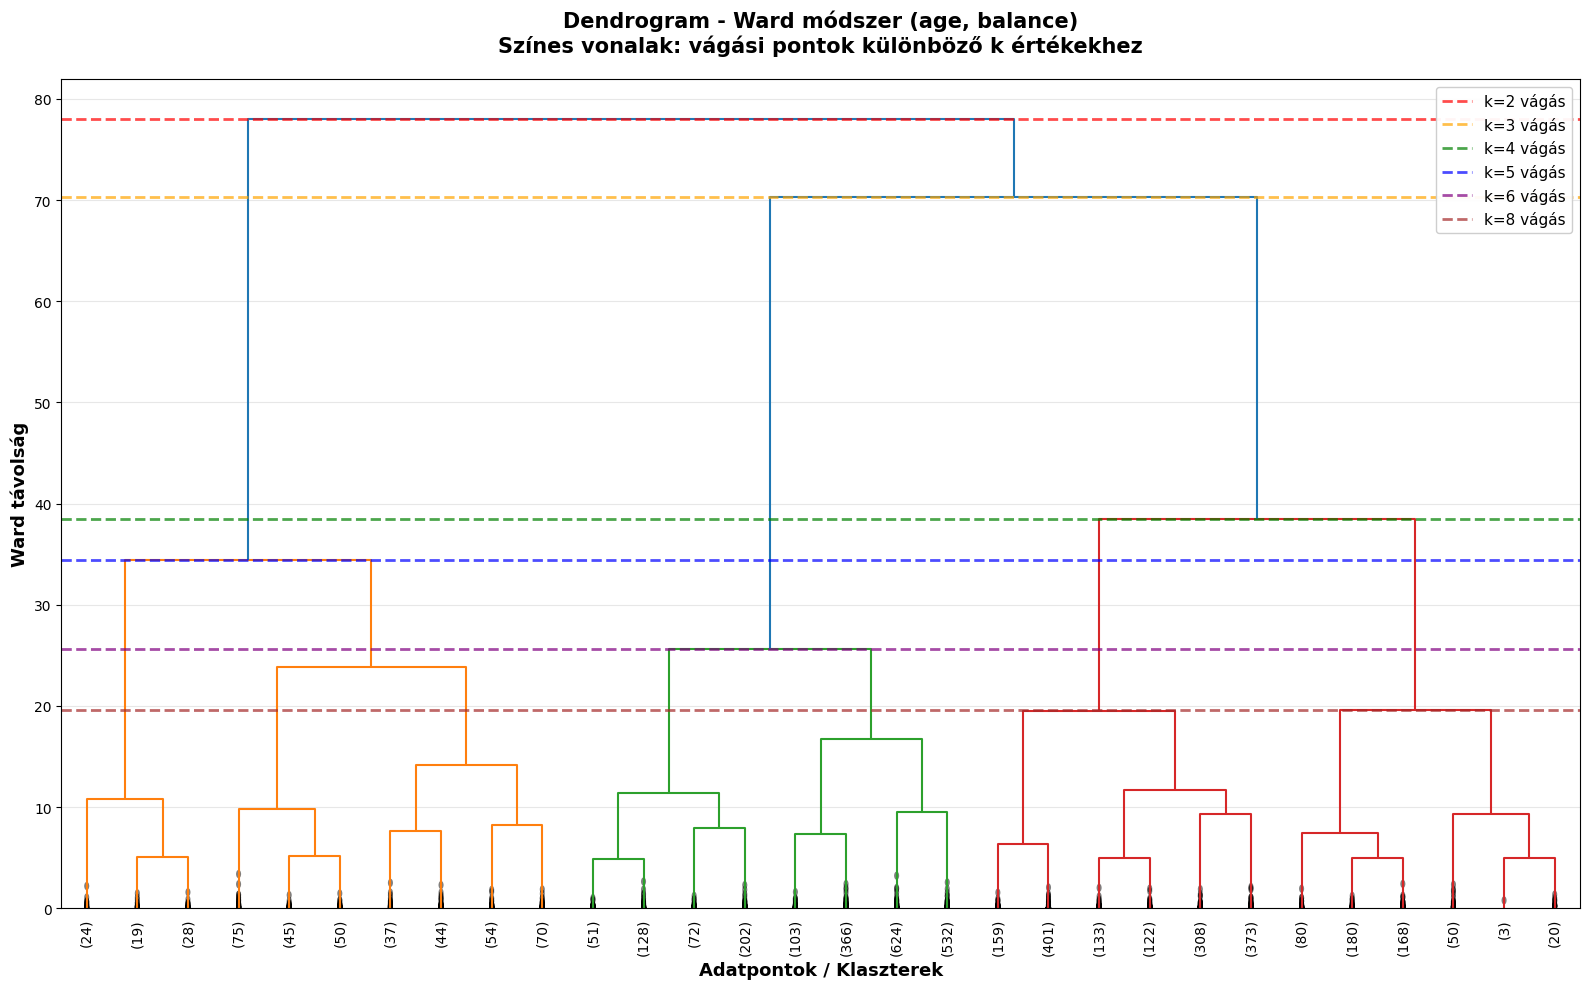

✓ Dendrogram mentve: exports_hacluster/dendrogram_ward.png


In [36]:
# Dendrogram vizualizáció
fig, ax = plt.subplots(figsize=(16, 10))

# Dendrogram - truncate mode a tisztább megjelenítéshez
dendr = dendrogram(
    Z,
    truncate_mode='lastp',  # Csak az utolsó p összevonást mutatja
    p=30,  # 30 utolsó összevonás
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    ax=ax
)

# Vágási vonalak jelölése különböző k értékekhez
# Vágási magasságok kiszámítása
cut_heights = {
    2: Z[-1, 2],  # Utolsó összevonás távolsága
    3: Z[-2, 2],  # Utolsó előtti összevonás távolsága
    4: Z[-3, 2],
    5: Z[-4, 2],
    6: Z[-5, 2],
    8: Z[-7, 2]
}

# Színes vízszintes vonalak a vágási pontokhoz
colors_cut = ['red', 'orange', 'green', 'blue', 'purple', 'brown']
for idx, (k, height) in enumerate(cut_heights.items()):
    ax.axhline(y=height, color=colors_cut[idx], linestyle='--', 
              linewidth=2, alpha=0.7, label=f'k={k} vágás')

ax.set_xlabel('Adatpontok / Klaszterek', fontsize=13, fontweight='bold')
ax.set_ylabel('Ward távolság', fontsize=13, fontweight='bold')
ax.set_title('Dendrogram - Ward módszer (age, balance)\n' +
            'Színes vonalak: vágási pontok különböző k értékekhez',
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('exports_hacluster/dendrogram_ward.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dendrogram mentve: exports_hacluster/dendrogram_ward.png")

## 5. Hierarchikus Klaszterezés - k=2-től k=8-ig

In [37]:
# Klaszterezés különböző k értékekkel
k_range = range(2, 9)  # k=2-től k=8-ig
results = []

print("="*90)
print("HIERARCHIKUS KLASZTEREZÉS - WARD MÓDSZER")
print("k értékek: 2-től 8-ig")
print("="*90)

for k in k_range:
    # AgglomerativeClustering
    hacluster = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hacluster.fit_predict(data_scaled)
    
    # Validációs metrikák
    silhouette = silhouette_score(data_scaled, labels)
    davies_bouldin = davies_bouldin_score(data_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(data_scaled, labels)
    
    results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
        'labels': labels
    })
    
    print(f"\nk = {k}:")
    print(f"  Silhouette Score:      {silhouette:.4f}")
    print(f"  Davies-Bouldin Index:  {davies_bouldin:.4f}")
    print(f"  Calinski-Harabasz:     {calinski_harabasz:.2f}")

print("\n" + "="*90)
print("✓ Hierarchikus klaszterezés befejezve minden k értékre!")
print("="*90)

HIERARCHIKUS KLASZTEREZÉS - WARD MÓDSZER
k értékek: 2-től 8-ig

k = 2:
  Silhouette Score:      0.5595
  Davies-Bouldin Index:  0.8856
  Calinski-Harabasz:     2294.14

k = 3:
  Silhouette Score:      0.4280
  Davies-Bouldin Index:  0.7952
  Calinski-Harabasz:     3536.43

k = 4:
  Silhouette Score:      0.3868
  Davies-Bouldin Index:  0.7815
  Calinski-Harabasz:     3382.56

k = 5:
  Silhouette Score:      0.3940
  Davies-Bouldin Index:  0.7621
  Calinski-Harabasz:     3523.49

k = 6:
  Silhouette Score:      0.3820
  Davies-Bouldin Index:  0.8521
  Calinski-Harabasz:     3471.46

k = 7:
  Silhouette Score:      0.3909
  Davies-Bouldin Index:  0.8557
  Calinski-Harabasz:     3544.80

k = 8:
  Silhouette Score:      0.3820
  Davies-Bouldin Index:  0.8264
  Calinski-Harabasz:     3548.51

✓ Hierarchikus klaszterezés befejezve minden k értékre!


## 6. Validációs Metrikák Exportálása

In [38]:
# Metrikák DataFrame
metrics_df = pd.DataFrame(results)[['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']]
metrics_df.columns = ['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']

print("\n" + "="*90)
print("VALIDÁCIÓS METRIKÁK ÖSSZEFOGLALÁSA")
print("="*90)
print(metrics_df.to_string(index=False))
print("="*90)

# Exportálás
metrics_df.to_csv('exports_hacluster/metrics_hacluster.csv', index=False, encoding='utf-8-sig')
print("\n✓ Metrikák exportálva: exports_hacluster/metrics_hacluster.csv")


VALIDÁCIÓS METRIKÁK ÖSSZEFOGLALÁSA
 k  silhouette  davies_bouldin  calinski_harabasz
 2    0.559490        0.885576        2294.139961
 3    0.428028        0.795173        3536.434761
 4    0.386789        0.781521        3382.560403
 5    0.394045        0.762104        3523.488464
 6    0.382005        0.852086        3471.458849
 7    0.390897        0.855710        3544.800642
 8    0.382011        0.826390        3548.512868

✓ Metrikák exportálva: exports_hacluster/metrics_hacluster.csv


## 7. Kétklaszteres Modell

In [39]:
k_two = metrics_df.loc[0, 'k'] #index 0 = k=2
k_two_result = results[0]

print(f"\nMetrikák (k=2):")
print(f"  Silhouette Score:      {k_two_result['silhouette']:.4f}")
print(f"  Davies-Bouldin Index:  {k_two_result['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz:     {k_two_result['calinski_harabasz']:.2f}")
print("="*90)

# k=2 összefoglaló
k2_summary = pd.DataFrame({
    'Metrika': ['Optimális k', 'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Érték': [
        k_two,
        k_two_result['silhouette'],
        k_two_result['davies_bouldin'],
        k_two_result['calinski_harabasz']
    ],
    'Megjegyzés': [
        'Legmagasabb Silhouette alapján',
        'Magasabb = jobb',
        'Alacsonyabb = jobb',
        'Magasabb = jobb'
    ]
})

# Exportálás
k2_summary.to_csv('exports_hacluster/k_two_summary.csv', index=False, encoding='utf-8-sig')
print("\n✓ k=2 összefoglaló exportálva: exports_hacluster/k_two_summary.csv")


Metrikák (k=2):
  Silhouette Score:      0.5595
  Davies-Bouldin Index:  0.8856
  Calinski-Harabasz:     2294.14

✓ k=2 összefoglaló exportálva: exports_hacluster/k_two_summary.csv


## 7.1 Háromklaszteres Modell

In [40]:
k_three = metrics_df.loc[1, 'k'] #index 1 = k=3
k_three_result = results[1]

print(f"\nMetrikák (k=3):")
print(f"  Silhouette Score:      {k_three_result['silhouette']:.4f}")
print(f"  Davies-Bouldin Index:  {k_three_result['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz:     {k_three_result['calinski_harabasz']:.2f}")
print("="*90)

# k=3 összefoglaló
k3_summary = pd.DataFrame({
    'Metrika': ['Optimális k', 'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Érték': [
        k_three,
        k_three_result['silhouette'],
        k_three_result['davies_bouldin'],
        k_three_result['calinski_harabasz']
    ],
    'Megjegyzés': [
        'Legalacsonyabb Davies-Bouldin arány és legmagasabb Calinski-Harabasz pontszám alapján',
        'Magasabb = jobb',
        'Alacsonyabb = jobb',
        'Magasabb = jobb'
    ]
})

# Exportálás
k3_summary.to_csv('exports_hacluster/k_three_summary.csv', index=False, encoding='utf-8-sig')
print("\n✓ k=3 összefoglaló exportálva: exports_hacluster/k_three_summary.csv")


Metrikák (k=3):
  Silhouette Score:      0.4280
  Davies-Bouldin Index:  0.7952
  Calinski-Harabasz:     3536.43

✓ k=3 összefoglaló exportálva: exports_hacluster/k_three_summary.csv


## 8. Scatter Plotok Minden k-hoz (k=2-8)


Scatter plotok generálása minden k értékhez...


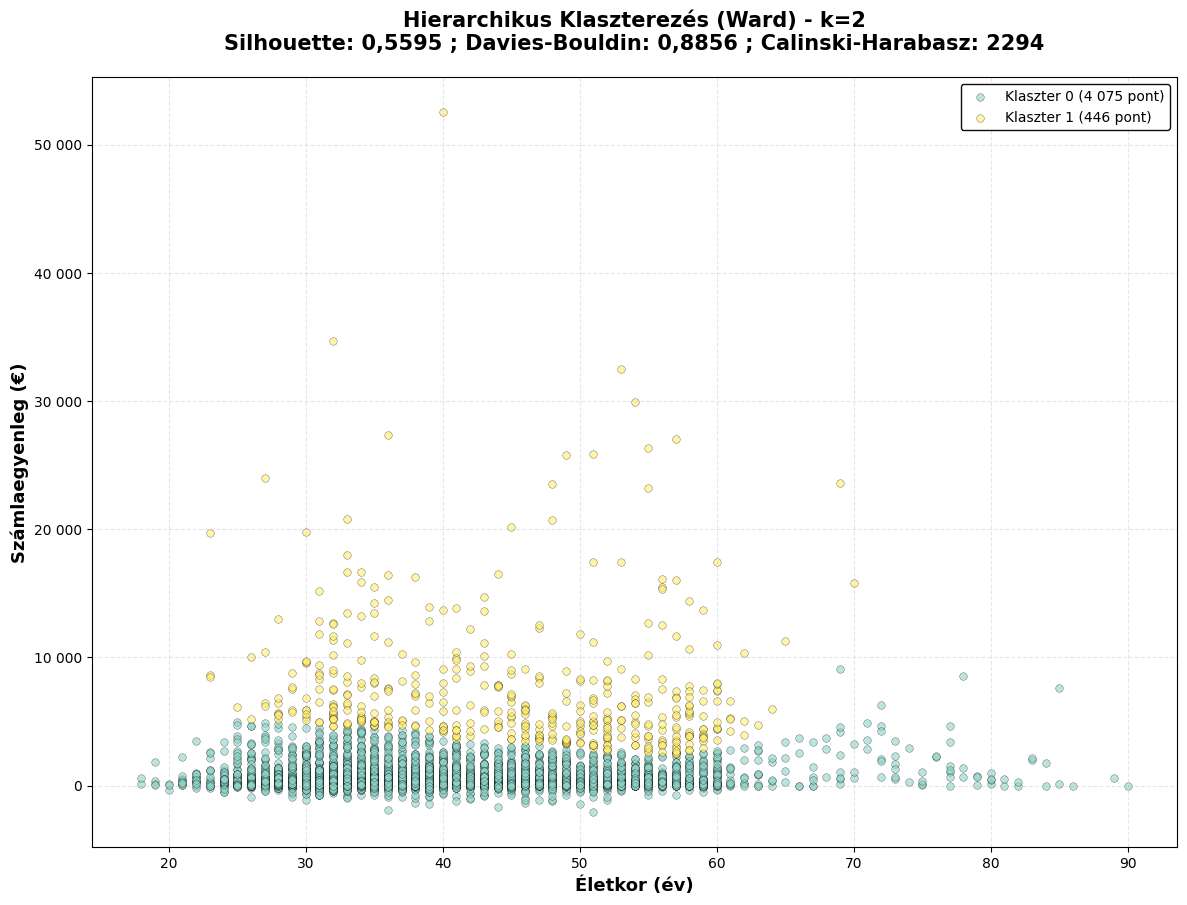

  ✓ hacluster_k2_scatter.png mentve


<Figure size 1400x800 with 0 Axes>

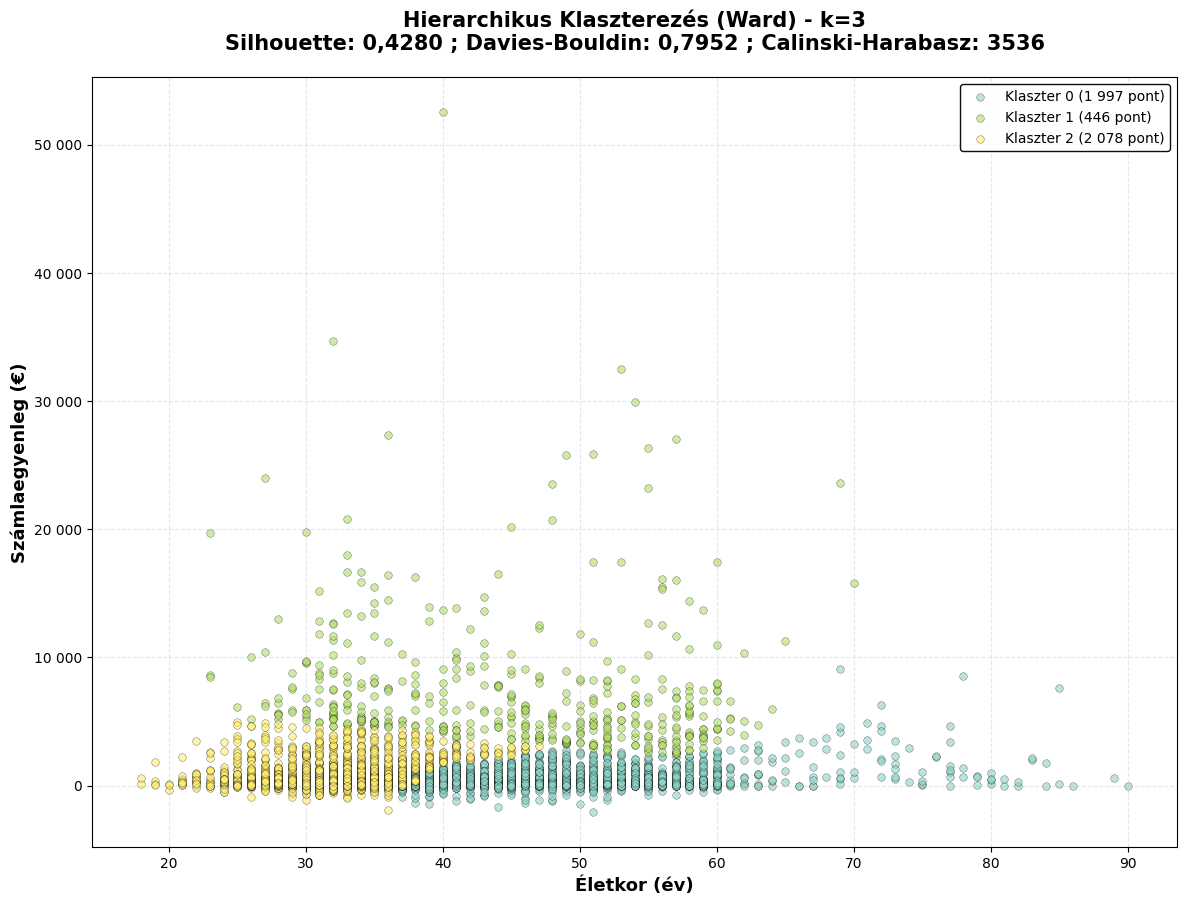

  ✓ hacluster_k3_scatter.png mentve


<Figure size 1400x800 with 0 Axes>

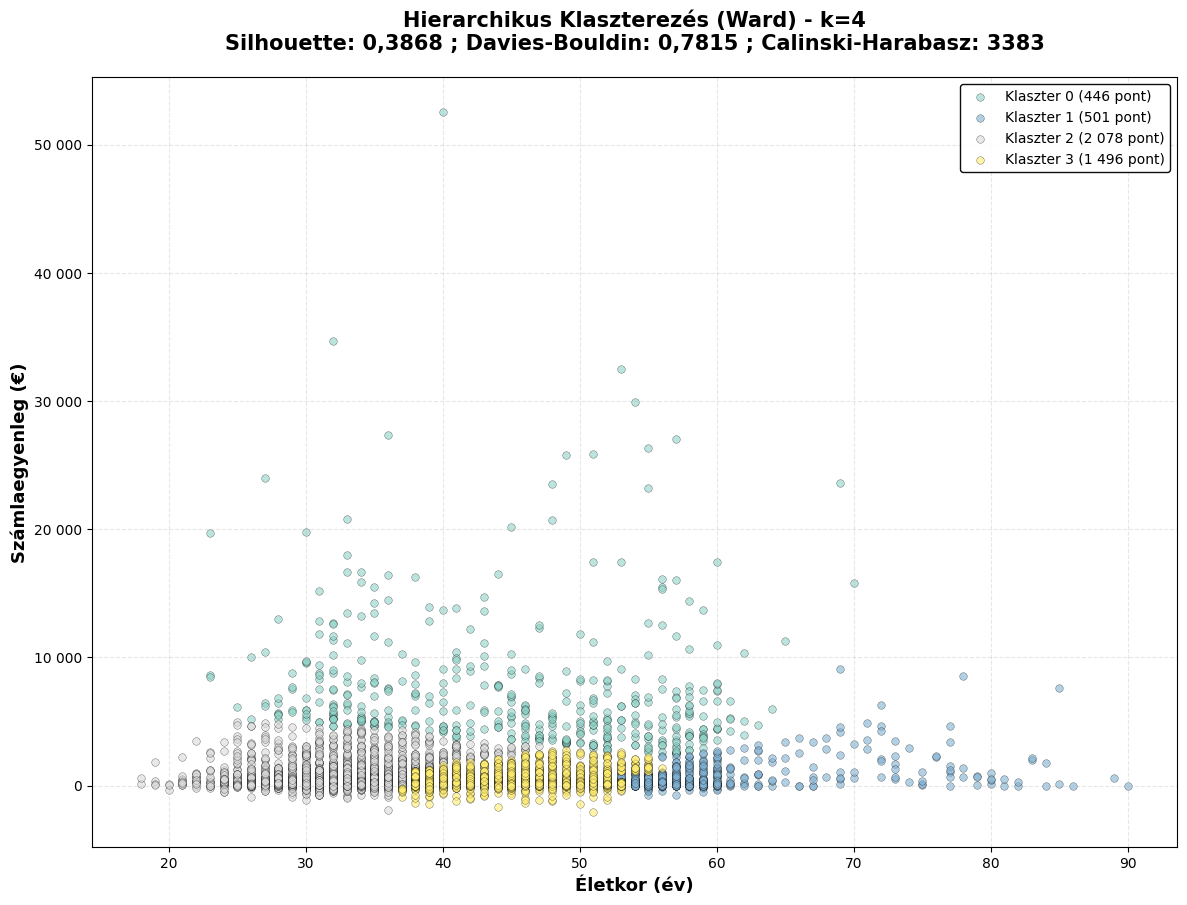

  ✓ hacluster_k4_scatter.png mentve


<Figure size 1400x800 with 0 Axes>

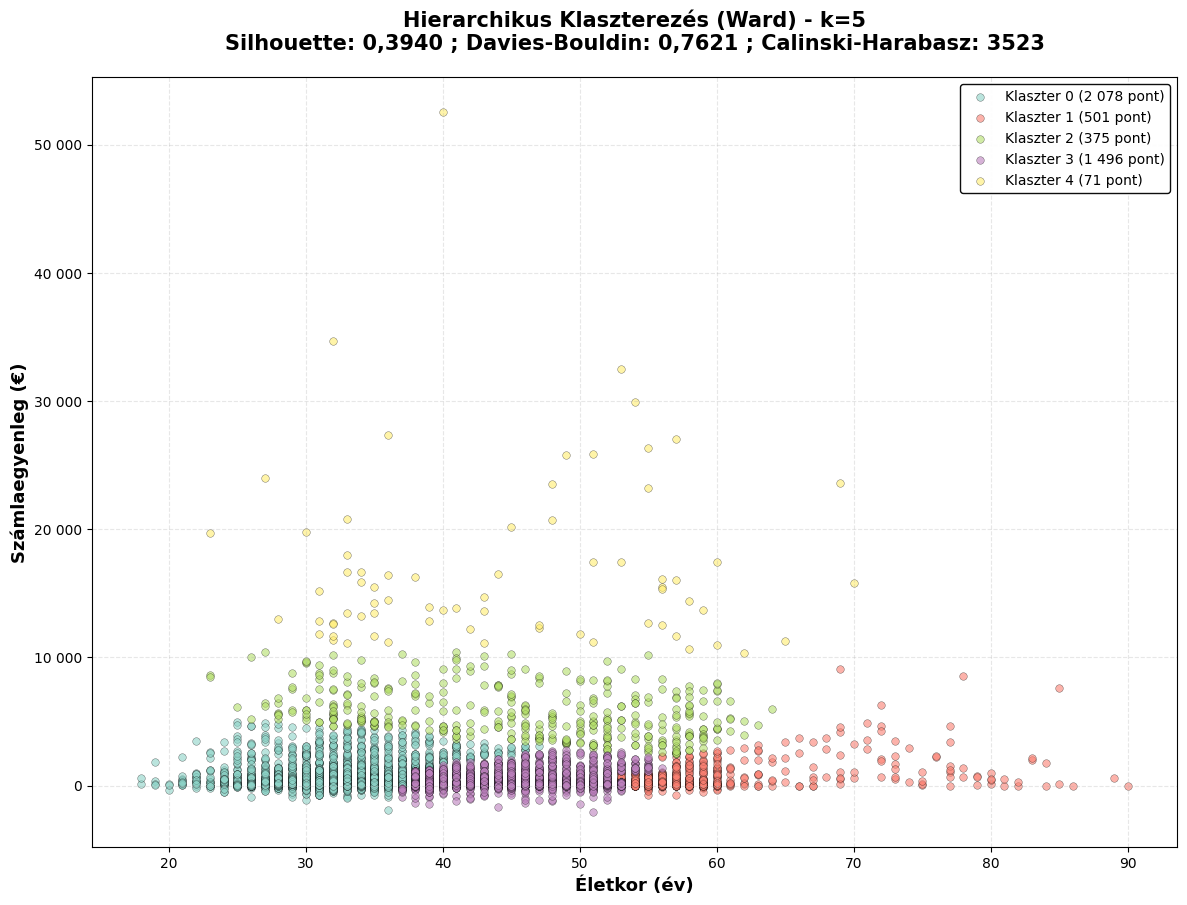

  ✓ hacluster_k5_scatter.png mentve


<Figure size 1400x800 with 0 Axes>

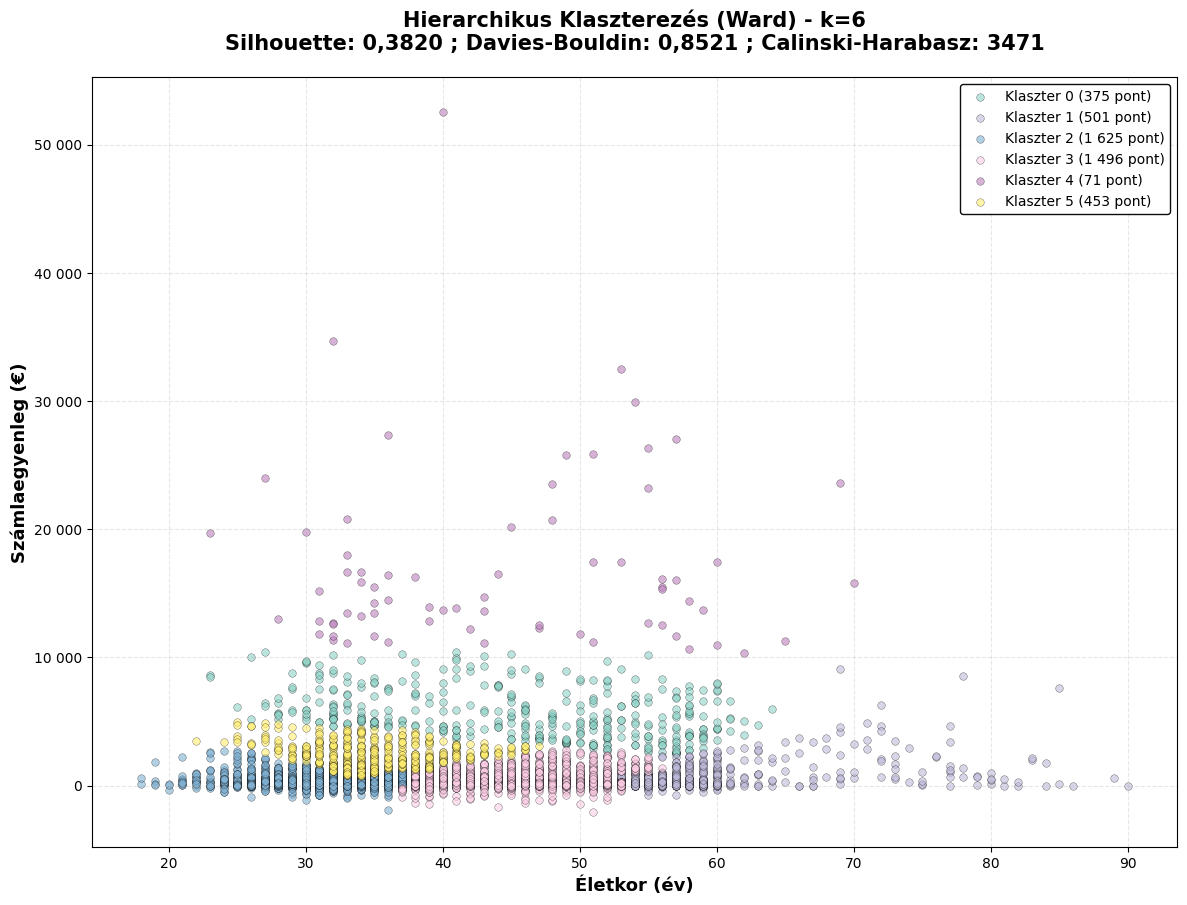

  ✓ hacluster_k6_scatter.png mentve


<Figure size 1400x800 with 0 Axes>

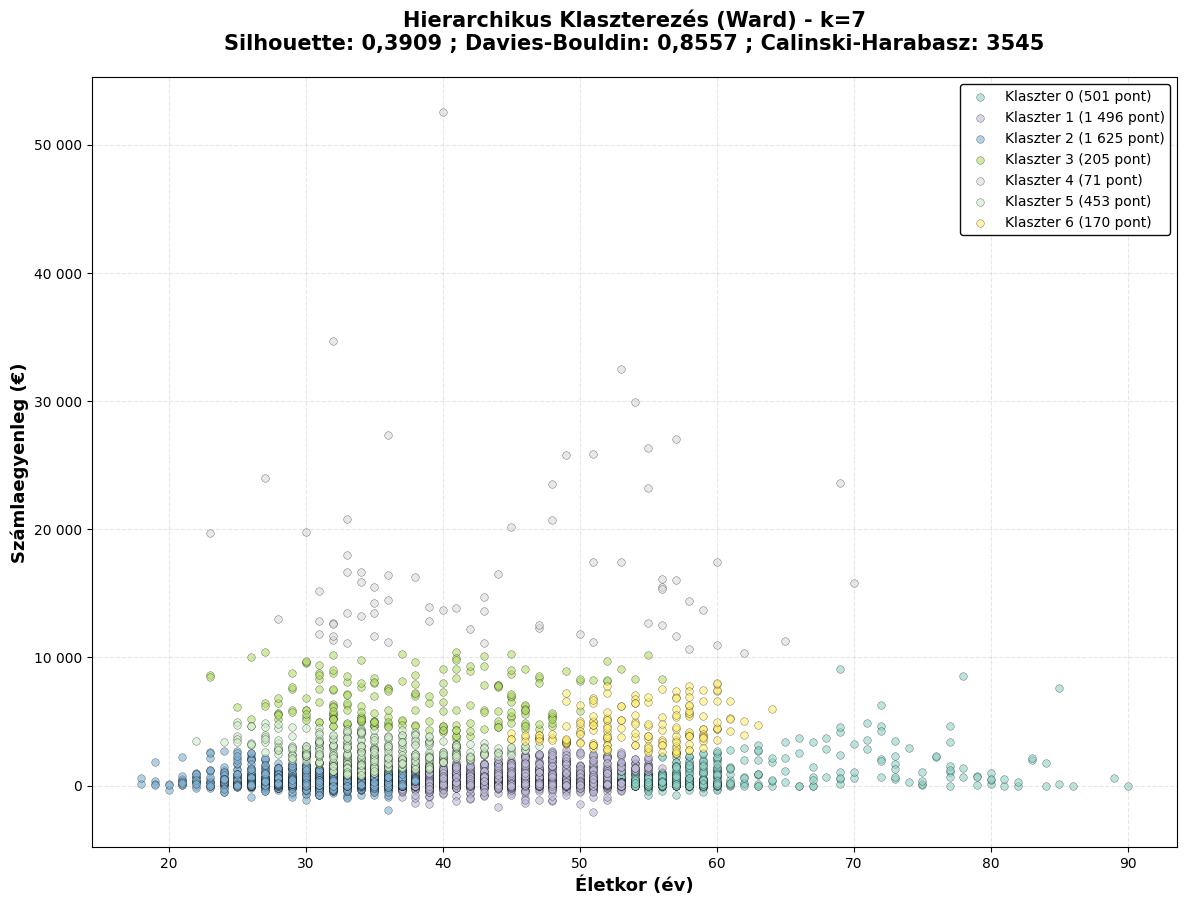

  ✓ hacluster_k7_scatter.png mentve


<Figure size 1400x800 with 0 Axes>

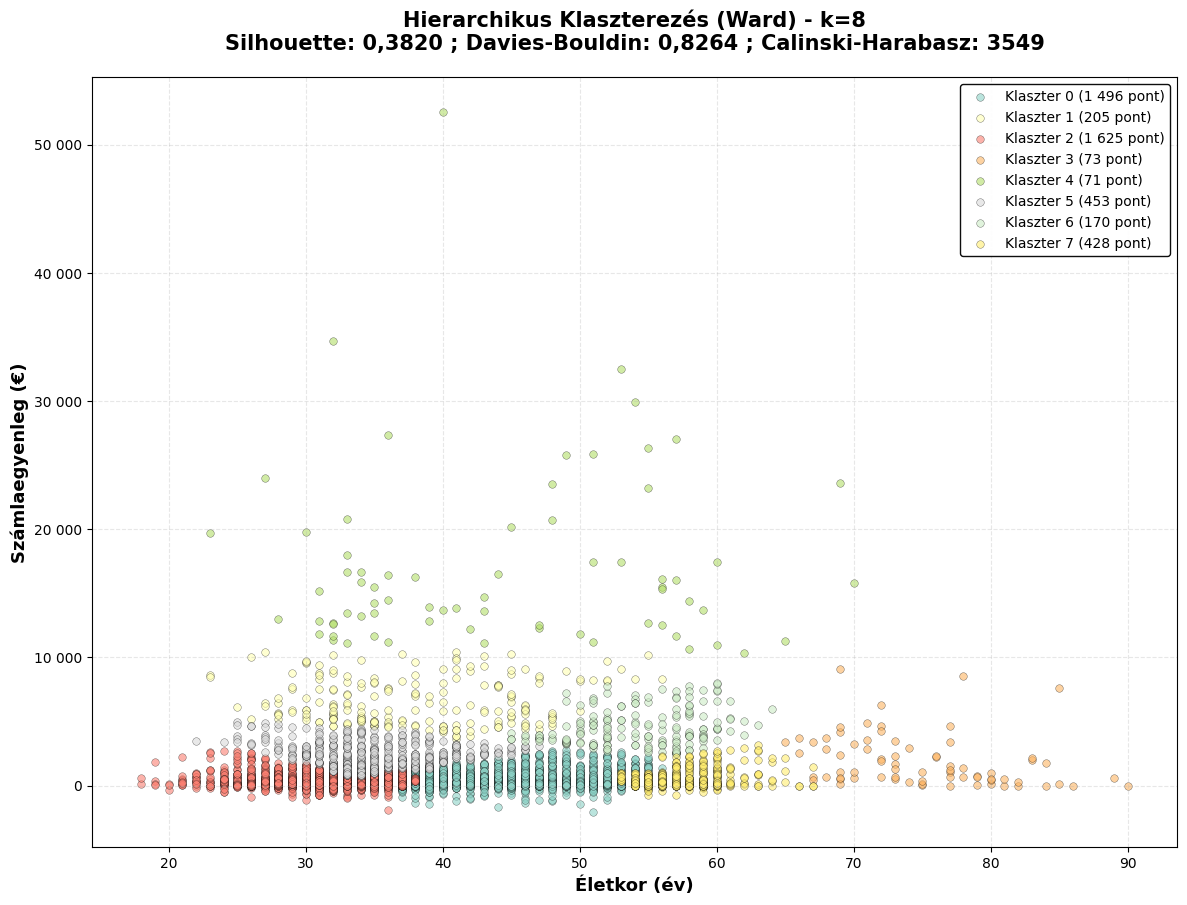

  ✓ hacluster_k8_scatter.png mentve

✓ Összes scatter plot mentve!


<Figure size 1400x800 with 0 Axes>

In [ ]:
# Scatter plotok minden k értékhez
print("\nScatter plotok generálása minden k értékhez...")

for result in results:
    k = result['k']
    labels = result['labels']
    
    # Átmeneti oszlop az ábrázoláshoz
    #    df_temp = df_sample.copy()
    df_temp = df.copy()
    df_temp['cluster_temp'] = labels
    
    # Scatter plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Színek
    colors = plt.cm.Set3(np.linspace(0, 1, k))
    
    for cluster_id in range(k):
        cluster_data = df_temp[df_temp['cluster_temp'] == cluster_id]
        ax.scatter(cluster_data['age'], cluster_data['balance'], 
                  label=f'Klaszter {cluster_id} ({len(cluster_data):,} pont)'.replace(',', ' '), 
                  alpha=0.6, s=30, c=[colors[cluster_id]], 
                  edgecolors='black', linewidths=0.3)
    
    # Címkék és formázás
    ax.set_xlabel('Életkor (év)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Számlaegyenleg (€)', fontsize=13, fontweight='bold')
    ax.set_title(f'Hierarchikus Klaszterezés (Ward) - k={k}\n' +
                f'Silhouette: {result["silhouette"]:.4f} ; '.replace('.', ',') +
                f'Davies-Bouldin: {result["davies_bouldin"]:.4f} ; '.replace('.', ',') +
                f'Calinski-Harabasz: {result["calinski_harabasz"]:.0f}',
                fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Y tengely formázása
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))
    
    plt.show()
    plt.tight_layout()
    plt.savefig(f'exports_hacluster/hacluster_k{k}_scatter.png', dpi=300, bbox_inches='tight')
    
    print(f"  ✓ hacluster_k{k}_scatter.png mentve")

print("\n✓ Összes scatter plot mentve!")

## 9. Metrikák Vizualizációja

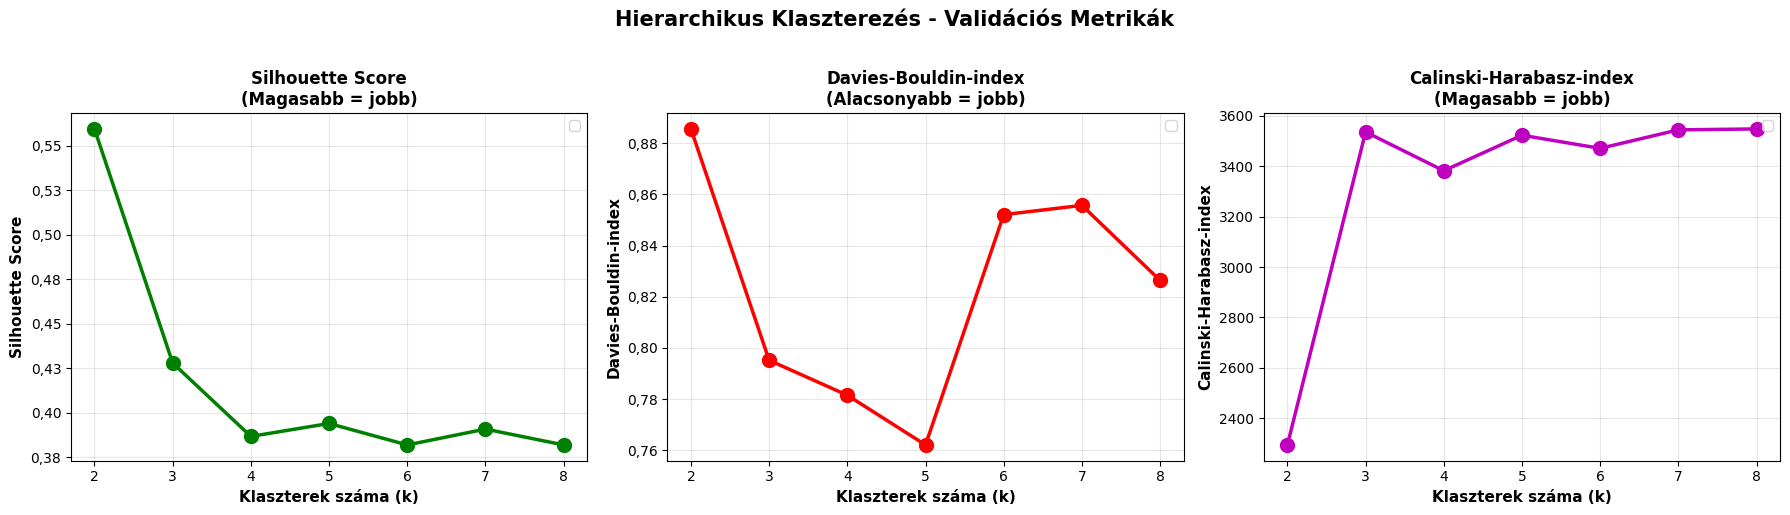

✓ Metrikák összehasonlító plot mentve: exports_hacluster/metrics_comparison.png


In [47]:
from matplotlib.ticker import FuncFormatter

def format_with_comma(x, pos):
        return f'{x:.2f}'.replace('.', ',')

# Metrikák vizualizációja 3 külön grafikonon
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
axes[0].plot(metrics_df['k'], metrics_df['silhouette'], 'go-', linewidth=2.5, markersize=10)
"""axes[0].scatter([k_two], [k_two_result['silhouette']], 
               color='red', s=300, zorder=5, marker='*', 
               edgecolors='darkred', linewidths=2, label=f'Optimális k={k_two}')
               """
axes[0].set_xlabel('Klaszterek száma (k)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[0].set_title('Silhouette Score\n(Magasabb = jobb)', fontsize=12, fontweight='bold')
axes[0].set_xticks(k_range)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(FuncFormatter(format_with_comma))

# Davies-Bouldin-index
axes[1].plot(metrics_df['k'], metrics_df['davies_bouldin'], 'ro-', linewidth=2.5, markersize=10)
"""axes[1].scatter([k_two], [k_two_result['davies_bouldin']], 
               color='green', s=300, zorder=5, marker='*', 
               edgecolors='darkgreen', linewidths=2, label=f'k={k_two}')
               """
axes[1].set_xlabel('Klaszterek száma (k)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Davies-Bouldin-index', fontsize=11, fontweight='bold')
axes[1].set_title('Davies-Bouldin-index\n(Alacsonyabb = jobb)', fontsize=12, fontweight='bold')
axes[1].set_xticks(k_range)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(FuncFormatter(format_with_comma))

# Calinski-Harabasz-index
axes[2].plot(metrics_df['k'], metrics_df['calinski_harabasz'], 'mo-', linewidth=2.5, markersize=10)
"""
axes[2].scatter([k_two], [k_two_result['calinski_harabasz']], 
               color='red', s=300, zorder=5, marker='*', 
               edgecolors='darkred', linewidths=2, label=f'Optimális k={k_two}')
               """
axes[2].set_xlabel('Klaszterek száma (k)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Calinski-Harabasz-index', fontsize=11, fontweight='bold')
axes[2].set_title('Calinski-Harabasz-index\n(Magasabb = jobb)', fontsize=12, fontweight='bold')
axes[2].set_xticks(k_range)
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)

plt.suptitle('Hierarchikus Klaszterezés - Validációs Metrikák', 
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exports_hacluster/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Metrikák összehasonlító plot mentve: exports_hacluster/metrics_comparison.png")

## 10. Klaszter Profilozás

In [ ]:
# k=2 címkék hozzáadása az adathalmazhoz
df['cluster_hacluster_2'] = k_two_result['labels']

# Klaszter profilozás
cluster_profiles = []

for cluster_id in range(k_two):
    cluster_data = df[df['cluster_hacluster_2'] == cluster_id]
    
    profile = {
        'Klaszter': cluster_id,
        'Átlag age': cluster_data['age'].mean(),
        'Szórás age': cluster_data['age'].std(),
        'Átlag balance': cluster_data['balance'].mean(),
        'Szórás balance': cluster_data['balance'].std(),
        'Elemszám (db)': len(cluster_data),
        'Elemszám (%)': len(cluster_data) / len(df) * 100
    }
    cluster_profiles.append(profile)

profiles_df = pd.DataFrame(cluster_profiles)

print("\n" + "="*100)
print(f"KLASZTER PROFILOZÁS k=2")
print("="*100)
print(profiles_df.to_string(index=False))
print("="*100)

# Exportálás
profiles_df.to_csv('exports_hacluster/cluster_profiles_hacluster_2.csv', 
                   index=False, encoding='utf-8-sig')
print("\n✓ Klaszter profilok exportálva: exports_hacluster/cluster_profiles_hacluster_2.csv")


KLASZTER PROFILOZÁS k=2
 Klaszter  Átlag age  Szórás age  Átlag balance  Szórás balance  Elemszám (db)  Elemszám (%)
        0  40.796665   10.567658     727.941056      996.235142          41616     92.048395
        1  42.551599   11.067547    8705.337135     6821.348773           3595      7.951605

✓ Klaszter profilok exportálva: exports_hacluster/cluster_profiles_hacluster_2.csv


In [ ]:
# k=3 címkék hozzáadása az adathalmazhoz
df['cluster_hacluster_3'] = k_three_result['labels']

# Klaszter profilozás
cluster_profiles = []

for cluster_id in range(k_three):
    cluster_data = df[df['cluster_hacluster_3'] == cluster_id]
    
    profile = {
        'Klaszter': cluster_id,
        'Átlag age': cluster_data['age'].mean(),
        'Szórás age': cluster_data['age'].std(),
        'Átlag balance': cluster_data['balance'].mean(),
        'Szórás balance': cluster_data['balance'].std(),
        'Elemszám (db)': len(cluster_data),
        'Elemszám (%)': len(cluster_data) / len(df) * 100
    }
    cluster_profiles.append(profile)

profiles_df = pd.DataFrame(cluster_profiles)

print("\n" + "="*100)
print(f"KLASZTER PROFILOZÁS k=3")
print("="*100)
print(profiles_df.to_string(index=False))
print("="*100)

# Exportálás
profiles_df.to_csv('exports_hacluster/cluster_profiles_hacluster_3.csv', 
                   index=False, encoding='utf-8-sig')
print("\n✓ Klaszter profilok exportálva: exports_hacluster/cluster_profiles_hacluster_3.csv")


KLASZTER PROFILOZÁS k=3
 Klaszter  Átlag age  Szórás age  Átlag balance  Szórás balance  Elemszám (db)  Elemszám (%)
        0  42.551599   11.067547    8705.337135     6821.348773           3595      7.951605
        1  50.695669    7.322606     828.399880     1074.566605          18263     40.395037
        2  33.055239    4.529124     649.378153      922.826849          23353     51.653359

✓ Klaszter profilok exportálva: exports_hacluster/cluster_profiles_hacluster_3.csv


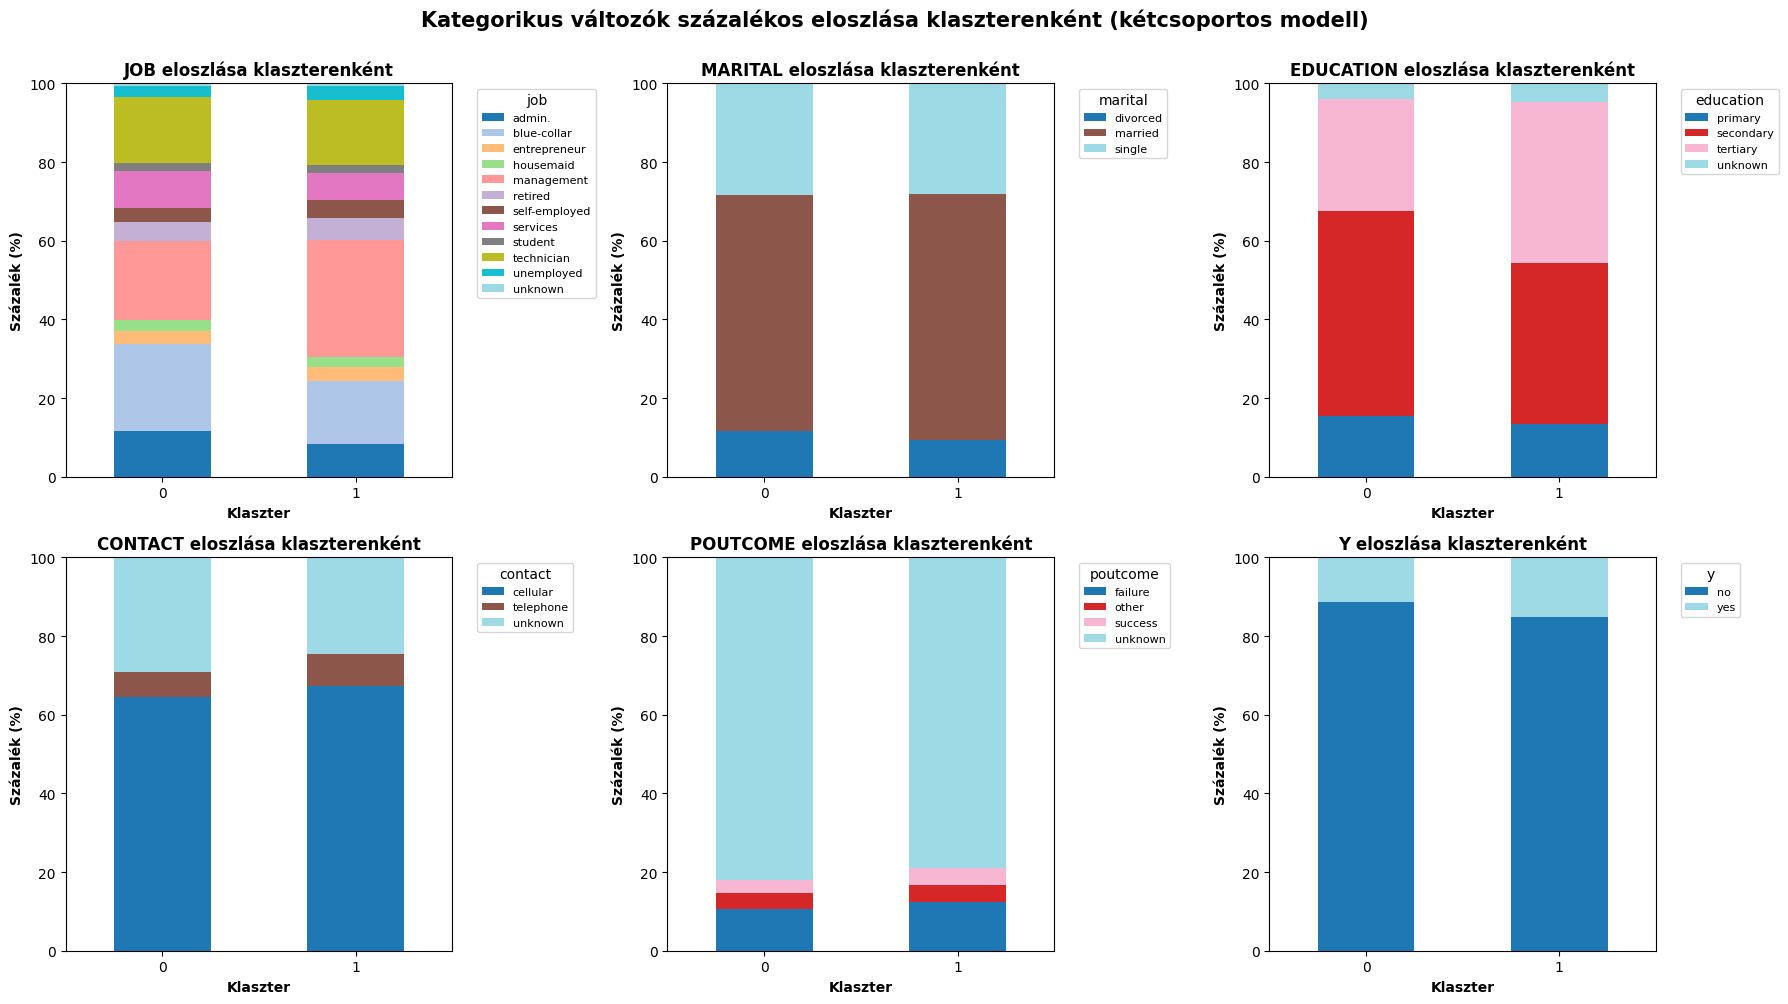

✓ Kategorikus eloszlások mentve: exports_hacluster/hacluster_categorical_distributions_k2.png


In [ ]:
# Vizualizáció - Stacked bar chart a fontosabb kategorikus változókra k=2
important_categorical = ['job', 'marital', 'education', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    ax = axes[idx]
    crosstab = pd.crosstab(df['cluster_hacluster_2'], df[col], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(f'{col.upper()} eloszlása klaszterenként', fontsize=12, fontweight='bold')
    ax.set_xlabel('Klaszter', fontsize=10, fontweight='bold')
    ax.set_ylabel('Százalék (%)', fontsize=10, fontweight='bold')
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim([0, 100])

plt.suptitle('Kategorikus változók százalékos eloszlása klaszterenként (kétcsoportos modell)', 
            fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('exports_hacluster/hacluster_categorical_distributions_k2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Kategorikus eloszlások mentve: exports_hacluster/hacluster_categorical_distributions_k2.png")

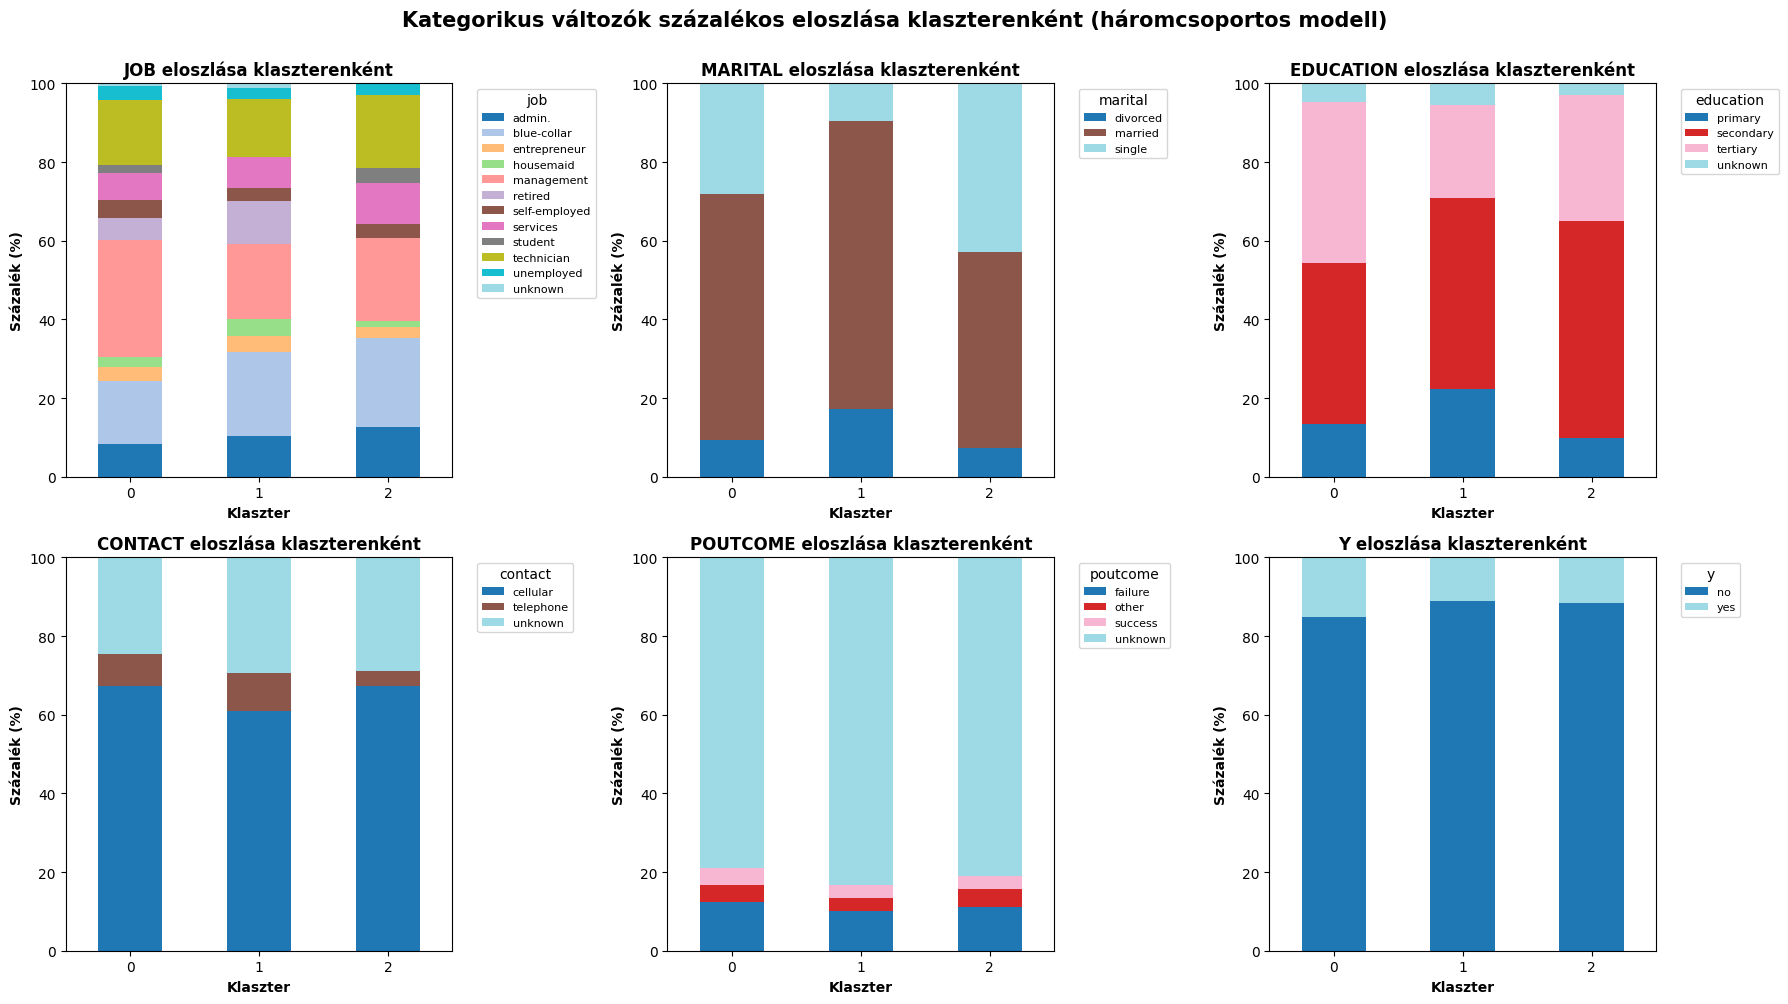

✓ Kategorikus eloszlások mentve: exports_hacluster/hacluster_categorical_distributions_k3.png


In [ ]:
# Vizualizáció - Stacked bar chart a fontosabb kategorikus változókra k=3
important_categorical = ['job', 'marital', 'education', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    ax = axes[idx]
    crosstab = pd.crosstab(df['cluster_hacluster_3'], df[col], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(f'{col.upper()} eloszlása klaszterenként', fontsize=12, fontweight='bold')
    ax.set_xlabel('Klaszter', fontsize=10, fontweight='bold')
    ax.set_ylabel('Százalék (%)', fontsize=10, fontweight='bold')
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim([0, 100])

plt.suptitle('Kategorikus változók százalékos eloszlása klaszterenként (háromcsoportos modell)', 
            fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('exports_hacluster/hacluster_categorical_distributions_k3.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Kategorikus eloszlások mentve: exports_hacluster/hacluster_categorical_distributions_k3.png")

## 11. Klaszterezett Adat Exportálása

In [ ]:
# Teljes adathalmaz exportálása cluster_hacluster oszloppal k=2
df.to_csv('exports_hacluster/clustered_data_hacluster_2.csv', index=False, encoding='utf-8-sig')

print("="*90)
print("KLASZTEREZETT ADAT EXPORTÁLÁSA")
print("="*90)
print(f"Fájl: clustered_data_hacluster_2.csv")
print(f"Sorok: {len(df):,}")
print(f"Oszlopok: {len(df.columns)} (eredeti + cluster_hacluster_2)")
print(f"\nKlaszter eloszlás:")
print(df['cluster_hacluster_2'].value_counts().sort_index())
print("="*90)

print("\n✓ Klaszterezett adathalmaz exportálva: exports_hacluster/clustered_data_hacluster_2.csv")

KLASZTEREZETT ADAT EXPORTÁLÁSA
Fájl: clustered_data_hacluster_2.csv
Sorok: 45,211
Oszlopok: 20 (eredeti + cluster_hacluster_2)

Klaszter eloszlás:
cluster_hacluster_2
0    18263
1     2932
2    23353
3      663
Name: count, dtype: int64

✓ Klaszterezett adathalmaz exportálva: exports_hacluster/clustered_data_hacluster_2.csv


In [ ]:
# Teljes adathalmaz exportálása cluster_hacluster oszloppal k=3
df.to_csv('exports_hacluster/clustered_data_hacluster_3.csv', index=False, encoding='utf-8-sig')

print("="*90)
print("KLASZTEREZETT ADAT EXPORTÁLÁSA")
print("="*90)
print(f"Fájl: clustered_data_hacluster_3.csv")
print(f"Sorok: {len(df):,}")
print(f"Oszlopok: {len(df.columns)} (eredeti + cluster_hacluster_3)")
print(f"\nKlaszter eloszlás:")
print(df['cluster_hacluster_3'].value_counts().sort_index())
print("="*90)

print("\n✓ Klaszterezett adathalmaz exportálva: exports_hacluster/clustered_data_hacluster_3.csv")

KLASZTEREZETT ADAT EXPORTÁLÁSA
Fájl: clustered_data_hacluster_3.csv
Sorok: 45,211
Oszlopok: 20 (eredeti + cluster_hacluster_3)

Klaszter eloszlás:
cluster_hacluster_3
0     9031
1     2932
2    23353
3      663
4     9232
Name: count, dtype: int64

✓ Klaszterezett adathalmaz exportálva: exports_hacluster/clustered_data_hacluster_3.csv
